# Mercy Health Data & Support Analyst — Data Analysis
### Case Studies in Data Science — Individual Task 1, Part 1.3

**Role:** Data and Support Analyst, Mercy Health

**Datasets:**
1. `data/curf_aged_care_needs_2025_extract.xlsx` — AIHW GEN Aged Care Data, *People's care needs in aged care* CURF (2025), filtered to permanent residential aged care residents.
2. `data/aihw_falls_hospitalisations_extract.xlsx` — AIHW Injury in Australia (INJCAT 213), *Falls Table 8*: hospitalisations due to falls by 5-year age group, sex and fall type, 2015–16 to 2024–25.

**Machine learning algorithms used:** Decision Tree and k-Nearest Neighbours (kNN). The same two algorithms are applied to each dataset; as a classifier on Dataset 1 and a regressor on Dataset 2, so that model behaviour can be compared consistently across both data sources.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error, r2_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42  # fixed seed everywhere below, for reproducible train/test splits and models
CLASS_ORDER = ["Not mobile", "Assisted mobility", "Independently mobile"]

## 1. Dataset 1 - CURF: People's care needs in aged care (2025)

This is a **confidentialised unit record file (CURF)**: one row per aged care resident, with de-identified demographic
attributes and their most recent care assessment. We use the `MOBILITY_CATEGORY` field (Not mobile / Assisted
mobility / Independently mobile) as the prediction target — a genuinely useful quantity for a Data & Support Analyst,
since mobility level drives staffing ratios, equipment needs (hoists, wheelchairs) and falls-prevention resourcing
in a residential home.

The raw CURF has 196,190 records across all care types; `data/curf_aged_care_needs_2025_extract.xlsx` has already
been filtered down (see `README.md`) to the ~195,700 permanent residential care records that have a known mobility
category, which is the population this model is meant to describe.

**Analytical question:** Can readily available demographic fields act as a proxy for a resident's
assessed mobility category when the clinical assessment itself isn't at hand? (See written analysis
for full discussion.)

In [2]:
# Load the extract already prepared for this notebook
curf = pd.read_excel("data/curf_aged_care_needs_2025_extract.xlsx")
print("Rows, columns:", curf.shape)
curf.head()

Rows, columns: (196190, 10)


,YEAR,STATE,CARE_TYPE,SEX,AGE_GROUP_5,INDIGENOUS_STATUS,PREFERRED_LANGUAGE,COUNTRY_OF_BIRTH,ANACC_CLASSIFICATION,MOBILITY_CATEGORY
0,2025,VIC,Permanent residential care,Male,80–84,Non-Indigenous,English,Australia,13,Not mobile
1,2025,WA,Permanent residential care,Male,80–84,Non-Indigenous,English,Other main-English-speaking country,11,Not mobile
2,2025,SA,Permanent residential care,Female,100+,Non-Indigenous,English,Australia,11,Not mobile
3,2025,WA,Permanent residential care,Male,80–84,Non-Indigenous,English,Other main-English-speaking country,4,Assisted mobility
4,2025,VIC,Permanent residential care,Female,80–84,Non-Indigenous,English,Australia,5,Assisted mobility


In [3]:
# Keep only the three substantive mobility categories.
# "Palliative care" and "Unknown" together make up <0.3% of records and are not
# comparable mobility levels, so we drop them rather than let a handful of rows
# distort a 3-class problem into an unstable 5-class one.
curf = curf[curf["MOBILITY_CATEGORY"].isin(CLASS_ORDER)].copy()
print(curf["MOBILITY_CATEGORY"].value_counts())

# Sample down to 20,000 rows purely so kNN (which has to compare every test point
# against every training point) trains and predicts in reasonable time in this
# notebook. The class balance of the sample is checked below to confirm it still
# reflects the full population.
if len(curf) > 20000:
    curf = curf.sample(20000, random_state=RANDOM_STATE)
print("\nAfter sampling:")
print(curf["MOBILITY_CATEGORY"].value_counts(normalize=True).round(3))

MOBILITY_CATEGORY
Assisted mobility       108829
Not mobile               82837
Independently mobile      4059
Name: count, dtype: int64

After sampling:
MOBILITY_CATEGORY
Assisted mobility       0.555
Not mobile              0.425
Independently mobile    0.020
Name: proportion, dtype: float64


**Note:** `Independently mobile` is a small minority class (~2%). Accuracy alone would be misleading
here, so macro-F1 and per-class recall are also reported — see written analysis for justification.

In [4]:
# Features: demographic and administrative fields available in the CURF as predictors.
# ANACC_CLASSIFICATION is deliberately excluded; it is derived from the same assessment as mobility
# category, so including it would leak the answer rather than test genuine predictive signal.
features_curf = ["SEX", "AGE_GROUP_5", "STATE", "INDIGENOUS_STATUS", "COUNTRY_OF_BIRTH", "PREFERRED_LANGUAGE"]
target_curf = "MOBILITY_CATEGORY"

X = curf[features_curf]
y = curf[target_curf]

print(f"Model sample size: {len(curf):,} rows")

majority_share = y.value_counts(normalize=True).max()
print(f"Naive 'always predict the majority class' baseline accuracy: {majority_share:.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Model sample size: 20,000 rows
Naive 'always predict the majority class' baseline accuracy: 55.5%
Train: (15000, 6)  Test: (5000, 6)


In [5]:
# All features are categorical; one-hot encode inside a Pipeline so the exact
# same encoding (fitted on the training set only) is applied consistently to test data.
preprocess_curf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_curf)
])

def evaluate_classifier(name, model, X_te, y_te):
    """Fit-agnostic helper: prints accuracy, macro-F1, per-class recall and the
    precision for the rare 'Independently mobile' class -- recall alone can hide
    a model that "catches" that class but is mostly wrong when it does."""
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1m = f1_score(y_te, pred, average="macro")
    rec = recall_score(y_te, pred, average=None, labels=CLASS_ORDER, zero_division=0)
    prec = precision_score(y_te, pred, average=None, labels=CLASS_ORDER, zero_division=0)
    print(f"{name:32s} accuracy={acc:.3f}  macro-F1={f1m:.3f}  "
          f"recall[Not mobile={rec[0]:.2f}, Assisted={rec[1]:.2f}, Independently mobile={rec[2]:.2f}]  "
          f"precision[Independently mobile={prec[2]:.2f}]")
    return pred, acc, f1m, rec

# Decision Tree, UNWEIGHTED (baseline)
dt_unweighted = Pipeline([
    ("prep", preprocess_curf),
    ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)),
])
dt_unweighted.fit(X_train, y_train)
pred_unw, acc_unw, f1_unw, rec_unw = evaluate_classifier("Decision Tree (unweighted)", dt_unweighted, X_test, y_test)

# Decision Tree, class-balanced (our chosen model A)
# class_weight="balanced" re-weights the training loss so the rare
# "Independently mobile" class is not simply ignored by the tree.
dt_clf = Pipeline([
    ("prep", preprocess_curf),
    ("model", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
])
dt_clf.fit(X_train, y_train)
dt_pred, dt_acc, dt_f1, rec_bal = evaluate_classifier("Decision Tree (balanced)", dt_clf, X_test, y_test)

# kNN (our chosen model B; scikit-learn's KNeighborsClassifier has no class_weight option)
knn_clf = Pipeline([
    ("prep", preprocess_curf),
    ("model", KNeighborsClassifier(n_neighbors=15)),
])
knn_clf.fit(X_train, y_train)
knn_pred, knn_acc, knn_f1, rec_knn = evaluate_classifier("kNN", knn_clf, X_test, y_test)

print("\nDecision Tree (balanced) full classification report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree (unweighted)       accuracy=0.547  macro-F1=0.286  recall[Not mobile=0.10, Assisted=0.91, Independently mobile=0.00]  precision[Independently mobile=0.00]
Decision Tree (balanced)         accuracy=0.333  macro-F1=0.276  recall[Not mobile=0.21, Assisted=0.42, Independently mobile=0.56]  precision[Independently mobile=0.03]
kNN                              accuracy=0.508  macro-F1=0.331  recall[Not mobile=0.38, Assisted=0.62, Independently mobile=0.00]  precision[Independently mobile=0.00]

Decision Tree (balanced) full classification report:

                      precision    recall  f1-score   support

   Assisted mobility       0.57      0.42      0.49      2774
Independently mobile       0.03      0.56      0.05       101
          Not mobile       0.48      0.21      0.29      2125

            accuracy                           0.33      5000
           macro avg       0.36      0.40      0.28      5000
        weighted avg       0.52      0.33      0.39      5000



**Note:** the balanced model does *not* have a higher macro-F1 than the unweighted one (0.276 vs 0.285)
— what it delivers is 0%→56% recall on the minority class, at the cost of very low precision (3%).
See written analysis for discussion of this trade-off.

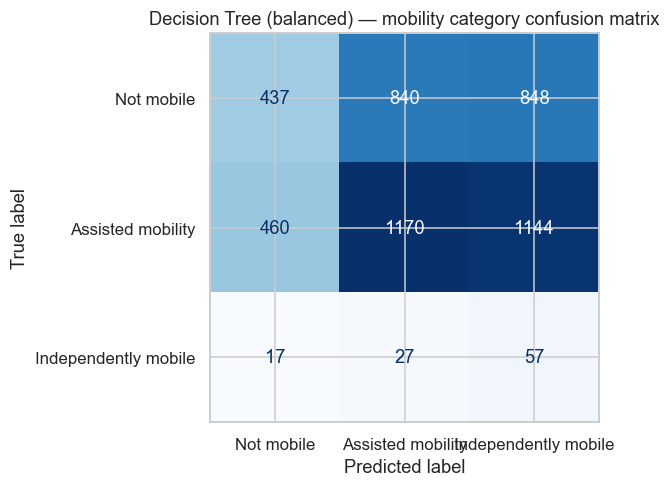

In [6]:
# Confusion matrix for the Decision Tree (balanced), to see exactly where mobility categories are confused
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred, labels=CLASS_ORDER, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Decision Tree (balanced) — mobility category confusion matrix")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", bbox_inches="tight")
plt.show()

**Reading the confusion matrix:** most errors sit between the two large adjacent classes (Assisted
mobility / Not mobile), consistent with demographics only partly explaining mobility.

### Figure 1 — Mobility profile by age group

This shows the share of residents in each mobility category, by age group.

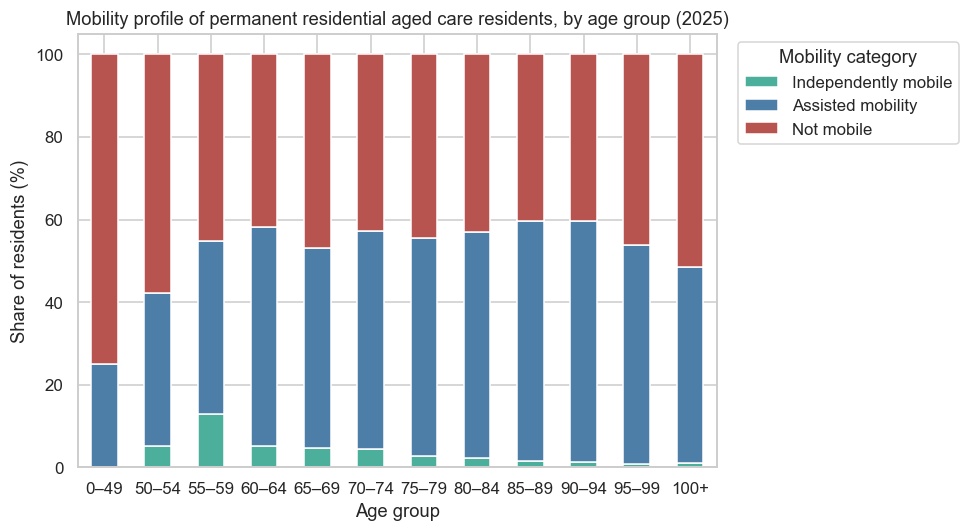

In [7]:
age_order = ["0\u201349", "50\u201354", "55\u201359", "60\u201364", "65\u201369", "70\u201374",
             "75\u201379", "80\u201384", "85\u201389", "90\u201394", "95\u201399", "100+"]

ct = pd.crosstab(curf["AGE_GROUP_5"], curf["MOBILITY_CATEGORY"], normalize="index") * 100
ct = ct.reindex([a for a in age_order if a in ct.index])

fig, ax = plt.subplots(figsize=(9, 5))
ct[["Independently mobile", "Assisted mobility", "Not mobile"]].plot(
    kind="bar", stacked=True, ax=ax, color=["#4CAF9C", "#4C7EA8", "#B85450"]
)
ax.set_ylabel("Share of residents (%)")
ax.set_xlabel("Age group")
ax.set_title("Mobility profile of permanent residential aged care residents, by age group (2025)")
ax.legend(title="Mobility category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/graph1_mobility_by_age.png", bbox_inches="tight")
plt.show()

## 2. Dataset 2 — AIHW Injury in Australia: falls hospitalisations (INJCAT 213, Falls Table 8)

This is **aggregate, published table data** (not unit records): hospitalisation counts due to falls by 5-year age
group, sex, detailed fall type and financial year, 2015–16 to 2024–25. We treat it as a regression problem —
predicting the number of `Hospitalisations` from the categorical descriptors of the group. **This is a count of
hospitalisations, not a population-adjusted rate** — the source table does not include population denominators, so
we describe results as "hospitalisations are concentrated in/among..." rather than claiming any group has a higher
*risk*.

In [8]:
falls = pd.read_excel("data/aihw_falls_hospitalisations_extract.xlsx")
print("Rows, columns:", falls.shape)
print("Financial years covered:", sorted(falls['FinancialYear'].unique()))
falls.head()

Rows, columns: (5622, 5)
Financial years covered: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


,FallType,AgeGroup,Sex,FinancialYear,Hospitalisations
0,All fall types (W00-W19),0–4,Males,2015-16,6029
1,All fall types (W00-W19),0–4,Males,2016-17,6008
2,All fall types (W00-W19),0–4,Males,2017-18,5840
3,All fall types (W00-W19),0–4,Males,2018-19,5965
4,All fall types (W00-W19),0–4,Males,2019-20,5600


**Note:** a time-based split (not random) is used here to avoid near-duplicate rows across adjacent
years leaking between train/test. `FinancialYear` is excluded as a feature since evaluation years are
never seen in training. See written analysis for full justification.

In [9]:
features_falls = ["FallType", "AgeGroup", "Sex"]   # FinancialYear used only for the split below, not as a feature
target_falls = "Hospitalisations"

train_years = ["2015-16", "2016-17", "2017-18", "2018-19", "2019-20", "2020-21", "2021-22"]
test_years = ["2022-23", "2023-24", "2024-25"]
train_mask = falls["FinancialYear"].isin(train_years)
test_mask = falls["FinancialYear"].isin(test_years)

Xf_train, yf_train = falls.loc[train_mask, features_falls], falls.loc[train_mask, target_falls]
Xf_test, yf_test = falls.loc[test_mask, features_falls], falls.loc[test_mask, target_falls]
print(f"Train: {len(Xf_train)} rows (2015-16 to 2021-22)   Test: {len(Xf_test)} rows (2022-23 to 2024-25, held out)")

preprocess_falls = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_falls)
])

# Model A: Decision Tree Regressor
dt_reg = Pipeline([
    ("prep", preprocess_falls),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
])

# Model B: k-Nearest Neighbours Regressor
knn_reg = Pipeline([
    ("prep", preprocess_falls),
    ("model", KNeighborsRegressor(n_neighbors=7)),
])

dt_reg.fit(Xf_train, yf_train)
knn_reg.fit(Xf_train, yf_train)

dt_reg_pred = dt_reg.predict(Xf_test)
knn_reg_pred = knn_reg.predict(Xf_test)

dt_mae = mean_absolute_error(yf_test, dt_reg_pred)
dt_r2 = r2_score(yf_test, dt_reg_pred)
knn_mae = mean_absolute_error(yf_test, knn_reg_pred)
knn_r2 = r2_score(yf_test, knn_reg_pred)

print(f"Decision Tree (held-out years) -> MAE={dt_mae:.1f} hospitalisations, R\u00b2={dt_r2:.3f}")
print(f"kNN (held-out years)           -> MAE={knn_mae:.1f} hospitalisations, R\u00b2={knn_r2:.3f}")

Train: 3942 rows (2015-16 to 2021-22)   Test: 1680 rows (2022-23 to 2024-25, held out)
Decision Tree (held-out years) -> MAE=202.7 hospitalisations, R²=0.972
kNN (held-out years)           -> MAE=118.1 hospitalisations, R²=0.978


**Note:** MAE and R² are used since this is a regression (count) target, not classification — see
written analysis for metric justification.

### Figure 2 — Falls hospitalisations by age and sex (most recent year)

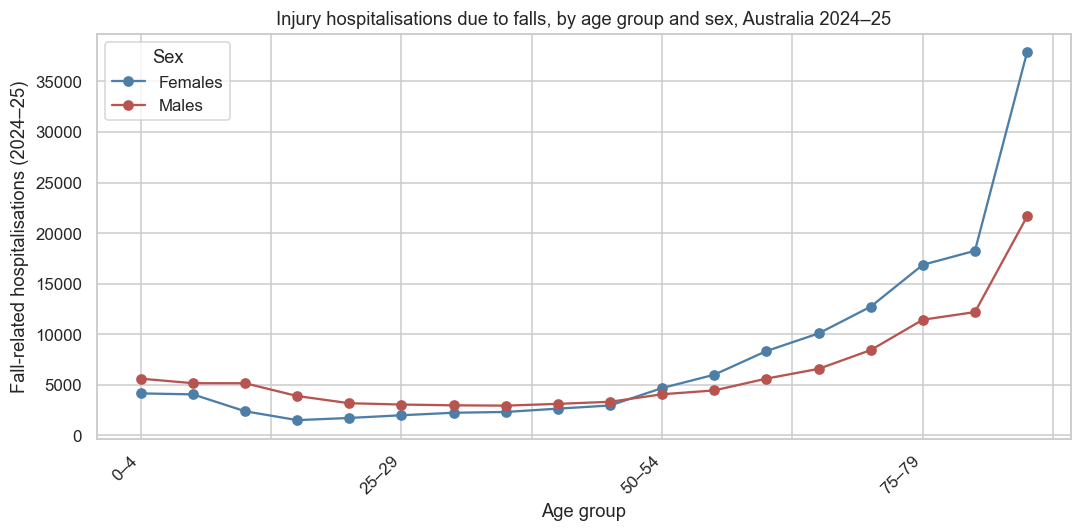

In [10]:
latest = falls[(falls["FinancialYear"] == "2024-25") & (falls["FallType"] == "All fall types (W00-W19)")]
age_order_f = ["0\u20134","5\u20139","10\u201314","15\u201319","20\u201324","25\u201329","30\u201334","35\u201339",
               "40\u201344","45\u201349","50\u201354","55\u201359","60\u201364","65\u201369","70\u201374","75\u201379",
               "80\u201384","85+"]
latest = latest[latest["AgeGroup"].isin(age_order_f)]
piv = latest.pivot_table(index="AgeGroup", columns="Sex", values="Hospitalisations").reindex(age_order_f)

fig, ax = plt.subplots(figsize=(10, 5))
piv.plot(kind="line", marker="o", ax=ax, color=["#4C7EA8", "#B85450"])
ax.set_ylabel("Fall-related hospitalisations (2024\u201325)")
ax.set_xlabel("Age group")
ax.set_title("Injury hospitalisations due to falls, by age group and sex, Australia 2024\u201325")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/graph2_falls_by_age_sex.png", bbox_inches="tight")
plt.show()

**Reading Figure 2:** counts, not population-adjusted rates — the source table has no denominator.


## 3. Model comparison across both datasets

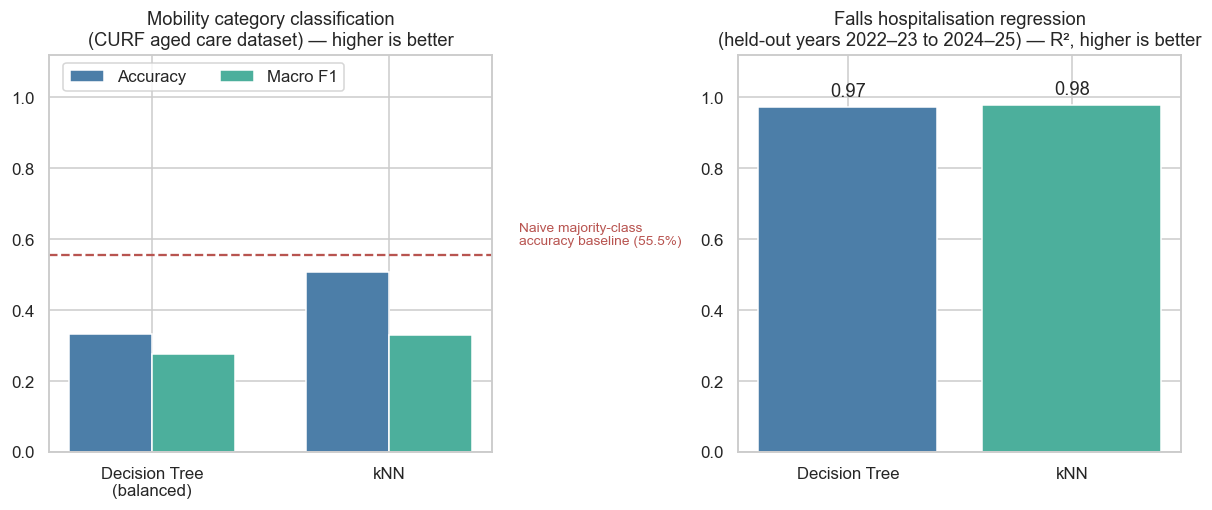

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Classification comparison (Dataset 1) 
models_c = ["Decision Tree\n(balanced)", "kNN"]
xw = np.arange(len(models_c))
width = 0.35
axes[0].bar(xw - width/2, [dt_acc, knn_acc], width, label="Accuracy", color="#4C7EA8")
axes[0].bar(xw + width/2, [dt_f1, knn_f1], width, label="Macro F1", color="#4CAF9C")
# Reference line: accuracy a naive "always predict the majority class" model would achieve.
# Neither model beats this on accuracy -- an important, honest caveat: their value comes from
# macro-F1 / minority-class recall, not from beating this trivial baseline on accuracy.
axes[0].axhline(majority_share, color="#B85450", linestyle="--", linewidth=1.5)
axes[0].text(1.55, majority_share + 0.02, f"Naive majority-class\naccuracy baseline ({majority_share:.1%})",
             color="#B85450", fontsize=9, va="bottom")
axes[0].set_xticks(xw); axes[0].set_xticklabels(models_c)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("Mobility category classification\n(CURF aged care dataset) \u2014 higher is better")
axes[0].legend(loc="upper center", ncol=2, bbox_to_anchor=(0.35, 1.0))

# Regression comparison (Dataset 2)
# Note: R² (0-1, higher is better) is not directly comparable to the accuracy/F1 scale on the
# left - these are two different metrics for two different task types, shown side by side only
# for convenience, not to imply "the falls model is better because 0.97 > 0.33".
r2_vals = [dt_r2, knn_r2]
axes[1].bar(["Decision Tree", "kNN"], r2_vals, color=["#4C7EA8", "#4CAF9C"])
axes[1].set_ylim(0, 1.12)
axes[1].set_title("Falls hospitalisation regression\n(held-out years 2022\u201323 to 2024\u201325) \u2014 R\u00b2, higher is better")
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("figures/model_comparison.png", bbox_inches="tight")
plt.show()

**Note**: Neither classifier beats the naive majority-class accuracy baseline (55.5%); see written analysis for discussion.